(257, 257)
Significant plateaus: 0 300 0
Significant plateaus: 0 400 0
Significant plateaus: 1 500 0
Significant plateaus: 1 600 0
Significant plateaus: 1 700 0
Significant plateaus: 0 800 0
Significant plateaus: 0 900 0
Significant plateaus: 0 1000 0


ValueError: num must be an integer with 1 <= num <= 8, not 9

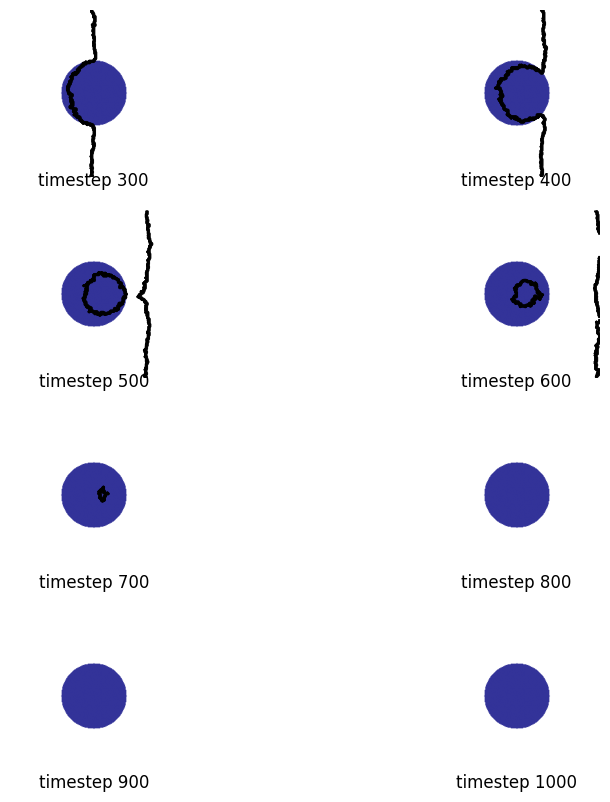

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d


# Parameters
sorrounding=0.8
plat=0.1
size = 257
radius=50
time=1500
threshold_randomness=0.5
damage_intensity=0.75
countor_levels=100
curvature_constant=0.3
erod_power=1

Ce = np.ones((size,size))*sorrounding

# Insert a resistant circular patch (Ce = 0)
cx, cy, r = 128, 128, radius
y, x = np.ogrid[:size, :size]
mask_resistant = (x - cx)**2 + (y - cy)**2 <= r**2
Ce[mask_resistant] = plat

erod=Ce.copy()

plt.figure(figsize=(10,10))

from scipy import ndimage
i=1


Mount= np.ones((size, size))
trans=Mount.T 
trans[0]=np.ones((1,size))*2
mount = trans.T
print(mount.shape)
damage= np.zeros((size,size))#size
threshold = 1.0 + threshold_randomness * np.random.randn(size, size)
snapshots=[]
lets=1
survivor=0


for dt in range(0,time):
    
        front = np.argwhere(mount == 2)
        for (x, y) in front:
            
            if mount[x][y]==2.0:
                if damage[x][y]>threshold[x][y]:
                    if x<size-1 and y<size-1:
                        if mount[x+1][y]==1: mount[x+1][y]=2
                        if mount[x][y+1]==1: mount[x][y+1]=2
                        if mount[x+1][y+1]==1: mount[x+1][y+1]=2    
                    if x>0 and y>0:                            
                        if mount[x-1][y]==1: mount[x-1][y]=2
                        if mount[x][y-1]==1: mount[x][y-1]=2
                        if mount[x-1][y-1]==1: mount[x-1][y-1]=2

                    if x>0 and y>0 and x<size-1 and y<size-1:      
                        if mount[x+1][y-1]==1: mount[x+1][y-1]=2
                        if mount[x-1][y+1]==1: mount[x-1][y+1]=2

                    mount[x][y]=0
                    
                else:
                    eroded_neighbors = 0
                    for dx in [-1, 0, 1]:
                        for dy in [-1, 0, 1]:
                            if (dx, dy) != (0, 0):
                                nx, ny = x + dx, y + dy
                                if 0 <= nx < size and 0 <= ny < size:
                                    if mount[nx, ny] == 0: 
                                        eroded_neighbors += 1

                    curvature = (eroded_neighbors - 4) / 4.0  
                    curvature_factor = 1 + curvature_constant * curvature      

                    damage[x][y] += (erod[x][y]**erod_power * damage_intensity * curvature_factor)


        structure = np.ones((3,3), int)
        plateaus = mount == 2
        structure = np.ones((3,3), dtype=bool)
        labeled, num_features = ndimage.label(plateaus, structure)

        # Create a mask for components that touch the boundary
        boundary_mask = np.zeros_like(labeled, dtype=bool)
        boundary_mask[0, :] = boundary_mask[-1, :] = True
        boundary_mask[:, 0] = boundary_mask[:, -1] = True

        # Find labels of features that touch the boundary
        boundary_labels = np.unique(labeled[boundary_mask])
        # Remove those features
        for label in boundary_labels:
            labeled[labeled == label] = 0

        # Recount remaining features
        sizes = ndimage.sum(plateaus, labeled, range(1, labeled.max() + 1))
        large_stru = np.sum(np.array(sizes) >= 8)
            
            
        if dt>=300 and dt<time:
            if dt%countor_levels==0:
                plt.subplot(4,2,i)
                plt.contour(mount, colors=['black'], alpha=0.6)
                plt.imshow(erod, cmap='terrain', origin='lower')
                plt.title("timestep " + str(dt), y=-0.1)
                plt.axis("off")
                print("Significant plateaus:", large_stru, dt, survivor)
                i+=1

            


#plt.imshow(erod, cmap='viridis', origin='lower')
#plt.colorbar(label='Erodibility (Ce)')
#plt.title('Contours')
plt.show()

(257, 257)
(257, 257) 0
(257, 257) 1
(257, 257) 2
(257, 257) 3
(257, 257) 4
(257, 257) 5
(257, 257) 6
(257, 257) 7
(257, 257) 8
(257, 257) 9
(257, 257) 10
(257, 257) 11
(257, 257) 12
(257, 257) 13
(257, 257) 14
(257, 257) 15
(257, 257) 16
(257, 257) 17
(257, 257) 18
(257, 257) 19
(257, 257) 20
(257, 257) 21
(257, 257) 22
(257, 257) 23
(257, 257) 24
(257, 257) 25
(257, 257) 26
(257, 257) 27
(257, 257) 28
(257, 257) 29
(257, 257) 30
(257, 257) 31
(257, 257) 32
(257, 257) 33
(257, 257) 34
(257, 257) 35
(257, 257) 36
(257, 257) 37
(257, 257) 38
(257, 257) 39
(257, 257) 40
(257, 257) 41
(257, 257) 42
(257, 257) 43
(257, 257) 44
(257, 257) 45
(257, 257) 46
(257, 257) 47
(257, 257) 48
(257, 257) 49
(257, 257) 50
(257, 257) 51
(257, 257) 52
(257, 257) 53
(257, 257) 54
(257, 257) 55
(257, 257) 56
(257, 257) 57
(257, 257) 58
(257, 257) 59
(257, 257) 60
(257, 257) 61
(257, 257) 62
(257, 257) 63
(257, 257) 64
(257, 257) 65
(257, 257) 66
(257, 257) 67
(257, 257) 68
(257, 257) 69
(257, 257) 70
(257,

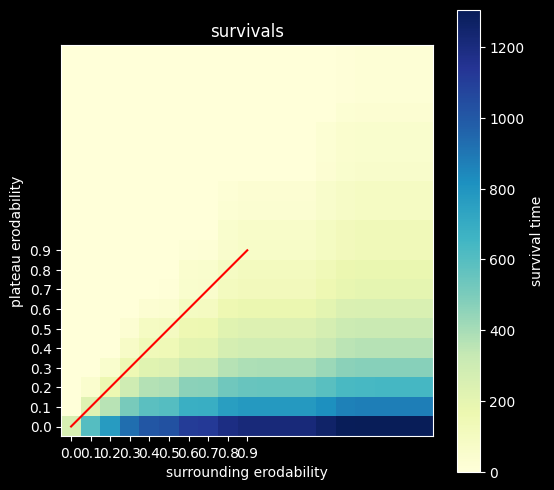

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d


# Parameters
sorrounding=0.8
plat=0.1
size = 257
radius=70
time=800
threshold_randomness=0.5
damage_intensity=0.75
countor_levels=100
curvature_constant=0.3
erod_power=1



plt.figure(figsize=(6,6))
plt.style.use('dark_background')

from scipy import ndimage
i=1


Mount= np.ones((size, size))
trans=Mount.T 
trans[0]=np.ones((1,size))*2
mount = trans.T
print(mount.shape)
damage= np.zeros((size,size))#size
threshold = 1.0 + threshold_randomness * np.random.randn(size, size)
survivals=[]
sorr=[]
final_sur=[]
dt=0

for plat_ in range(5,45,2):
    survivals=[]
    for sorrounding_ in range(10,101,5):
        sorrounding=sorrounding_/100
        plat=plat_/100
        Ce = np.ones((size,size))*sorrounding
    
        Mount= np.ones((size, size))
        trans=Mount.T 
        trans[0]=np.ones((1,size))*2
        mount = trans.T
        print(mount.shape,dt)
        damage= np.zeros((size,size))#size
        threshold = 1.0 + threshold_randomness * np.random.randn(size, size)*0    #change
    
        survivor=0

        cx, cy, r = 128, 128, radius
        y, x = np.ogrid[:size, :size]
        mask_resistant = (x - cx)**2 + (y - cy)**2 <= r**2
        Ce[mask_resistant] = plat

        erod=Ce.copy()
        count_2s = np.count_nonzero(mount == 2)
      
        if sorrounding>plat:
            while count_2s !=0 :
                front = np.argwhere(mount == 2)
                for (x, y) in front:   
                    if mount[x][y]==2.0:
                        if damage[x][y]>threshold[x][y]:
                            if x<size-1 and y<size-1:
                                if mount[x+1][y]==1: mount[x+1][y]=2
                                if mount[x][y+1]==1: mount[x][y+1]=2
                                if mount[x+1][y+1]==1: mount[x+1][y+1]=2    
                            if x>0 and y>0:                            
                                if mount[x-1][y]==1: mount[x-1][y]=2
                                if mount[x][y-1]==1: mount[x][y-1]=2
                                if mount[x-1][y-1]==1: mount[x-1][y-1]=2
                                    
                            if x>0 and y>0 and x<size-1 and y<size-1:      
                                if mount[x+1][y-1]==1: mount[x+1][y-1]=2
                                if mount[x-1][y+1]==1: mount[x-1][y+1]=2
                            mount[x][y]=0   
                        else:
                            eroded_neighbors = 0
                            for dx in [-1, 0, 1]:
                                for dy in [-1, 0, 1]:
                                    if (dx, dy) != (0, 0):
                                        nx, ny = x + dx, y + dy
                                        if 0 <= nx < size and 0 <= ny < size:
                                            if mount[nx, ny] == 0: 
                                                eroded_neighbors += 1
                        curvature = (eroded_neighbors - 4) / 4.0  
                        curvature_factor = 1 + curvature_constant * curvature      
                        damage[x][y] += (erod[x][y]**erod_power * damage_intensity * curvature_factor)
        
                count_2s = np.count_nonzero(mount == 2)
                plateaus = mount == 2
                structure = np.ones((3,3), dtype=bool)
                labeled, num_features = ndimage.label(plateaus, structure)

        # Create a mask for components that touch the boundary
                boundary_mask = np.zeros_like(labeled, dtype=bool)
                boundary_mask[0, :] = boundary_mask[-1, :] = True
                boundary_mask[:, 0] = boundary_mask[:, -1] = True

        # Find labels of features that touch the boundary
                boundary_labels = np.unique(labeled[boundary_mask])
        # Remove those features
                for label in boundary_labels:
                    labeled[labeled == label] = 0

        # Recount remaining features
                sizes = ndimage.sum(plateaus, labeled, range(1, labeled.max() + 1))
                large_stru = np.sum(np.array(sizes) >= 8)

                if large_stru>=1:
                    survivor+=1
                
            survivals.append(survivor)
        
        else:
            survivals.append(0)

        dt+=1

    final_sur.append(survivals)

A=np.array(final_sur)
plt.imshow(A, cmap='YlGnBu', origin='lower')
plt.colorbar(label='survival time')
plt.xticks(np.arange(10), np.arange(10)/10)
plt.xlabel("surrounding erodability")
plt.yticks(np.arange(10), np.arange(10)/10)
plt.ylabel("plateau erodability")
plt.title('survivals')
x=np.arange(10)
plt.plot(x, x, color='red', linestyle='-')
plt.show()

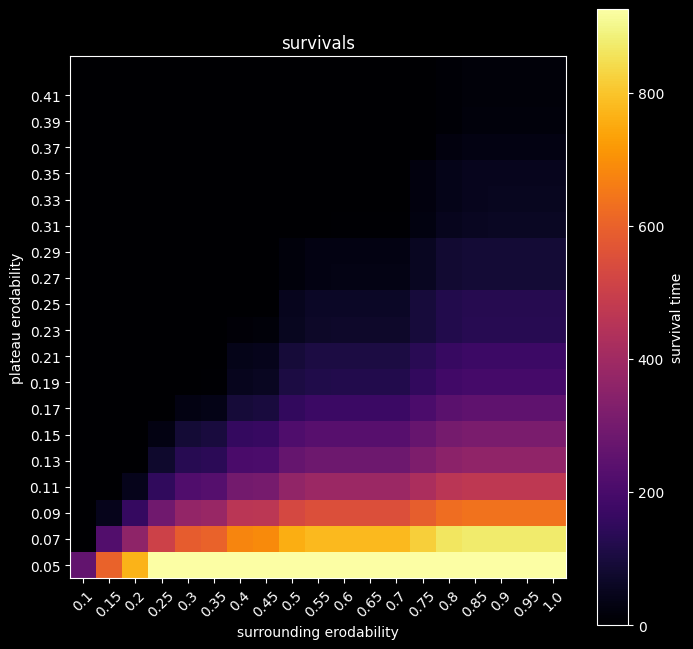

In [19]:
plt.figure(figsize=(8,8))
plt.imshow(A, cmap='inferno', origin='lower',vmin=0,vmax=926)
plt.colorbar(label='survival time')
plt.xticks(np.arange(19), (np.arange(19)*5+10)/100,rotation=45)
plt.xlabel("surrounding erodability")
plt.yticks(np.arange(19), (np.arange(19)*2+5)/100)
plt.ylabel("plateau erodability")
plt.title('survivals')
x=np.arange(20)
#plt.plot(x, x, color='red', linestyle='-')
plt.savefig("C:/ECS/survivals_cir_r70.png")
plt.show()

(257, 257)
(257, 257) 0
(257, 257) 1
(257, 257) 2
(257, 257) 3
(257, 257) 4
(257, 257) 5
(257, 257) 6
(257, 257) 7
(257, 257) 8
(257, 257) 9
(257, 257) 10
(257, 257) 11
(257, 257) 12
(257, 257) 13
(257, 257) 14
(257, 257) 15
(257, 257) 16
(257, 257) 17
(257, 257) 18
(257, 257) 19
(257, 257) 20
(257, 257) 21
(257, 257) 22
(257, 257) 23
(257, 257) 24
(257, 257) 25
(257, 257) 26
(257, 257) 27
(257, 257) 28
(257, 257) 29
(257, 257) 30
(257, 257) 31
(257, 257) 32
(257, 257) 33
(257, 257) 34
(257, 257) 35
(257, 257) 36
(257, 257) 37
(257, 257) 38
(257, 257) 39
(257, 257) 40
(257, 257) 41
(257, 257) 42
(257, 257) 43
(257, 257) 44
(257, 257) 45
(257, 257) 46
(257, 257) 47
(257, 257) 48
(257, 257) 49
(257, 257) 50
(257, 257) 51
(257, 257) 52
(257, 257) 53
(257, 257) 54
(257, 257) 55
(257, 257) 56
(257, 257) 57
(257, 257) 58
(257, 257) 59
(257, 257) 60
(257, 257) 61
(257, 257) 62
(257, 257) 63
(257, 257) 64
(257, 257) 65
(257, 257) 66
(257, 257) 67
(257, 257) 68
(257, 257) 69
(257, 257) 70
(257,

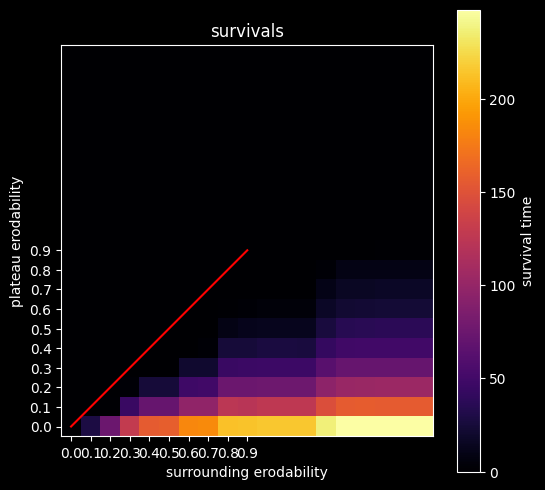

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d


# Parameters
sorrounding=0.8
plat=0.1
size = 257
radius=50
time=800
threshold_randomness=0.5
damage_intensity=0.75
countor_levels=100
curvature_constant=0.3
erod_power=1



plt.figure(figsize=(6,6))
plt.style.use('dark_background')

from scipy import ndimage
i=1


Mount= np.ones((size, size))
trans=Mount.T 
trans[0]=np.ones((1,size))*2
mount = trans.T
print(mount.shape)
damage= np.zeros((size,size))#size
threshold = 1.0 + threshold_randomness * np.random.randn(size, size)
survivals=[]
sorr=[]
final_sur=[]
dt=0

for plat_ in range(5,45,2):
    survivals=[]
    for sorrounding_ in range(10,101,5):
        sorrounding=sorrounding_/100
        plat=plat_/100
        Ce = np.ones((size,size))*sorrounding
    
        Mount= np.ones((size, size))
        trans=Mount.T 
        trans[0]=np.ones((1,size))*2
        mount = trans.T
        print(mount.shape, dt)
        damage= np.zeros((size,size))#size
        threshold = 1.0 + threshold_randomness * np.random.randn(size, size)*0    #change
    
        survivor=0

        cx, cy, r, half_side = 128, 128, radius, 40

# Center of the image
        cx, cy = size // 2, size // 2

# Triangle size — choose the side length
        side = 50  # you can adjust this

# Height of an equilateral triangle
        h = np.sqrt(3) / 2 * side

# Define vertices (pointing to the right)
# Base vertical, centered at (cx, cy)
        p1 = np.array([cx + side / 2, cy - h / 2])
        p2 = np.array([cx + side / 2, cy + h / 2])
        p3 = np.array([cx - side / 2, cy])
# Create grid
        y, x = np.ogrid[:size, :size]

# Barycentric coordinate method
        denom = ((p2[1] - p3[1]) * (p1[0] - p3[0]) + (p3[0] - p2[0]) * (p1[1] - p3[1]))
        a = ((p2[1] - p3[1]) * (x - p3[0]) + (p3[0] - p2[0]) * (y - p3[1])) / denom
        b = ((p3[1] - p1[1]) * (x - p3[0]) + (p1[0] - p3[0]) * (y - p3[1])) / denom
        c = 1 - a - b

# Mask of points inside the triangle
        mask_triangle = (a >= 0) & (b >= 0) & (c >= 0)
        Ce[mask_triangle] = plat


        erod=Ce.copy()
        count_2s = np.count_nonzero(mount == 2)
      
        if sorrounding>plat:
            while count_2s !=0 :
                front = np.argwhere(mount == 2)
                for (x, y) in front:   
                    if mount[x][y]==2.0:
                        if damage[x][y]>threshold[x][y]:
                            if x<size-1 and y<size-1:
                                if mount[x+1][y]==1: mount[x+1][y]=2
                                if mount[x][y+1]==1: mount[x][y+1]=2
                                if mount[x+1][y+1]==1: mount[x+1][y+1]=2    
                            if x>0 and y>0:                            
                                if mount[x-1][y]==1: mount[x-1][y]=2
                                if mount[x][y-1]==1: mount[x][y-1]=2
                                if mount[x-1][y-1]==1: mount[x-1][y-1]=2
                                    
                            if x>0 and y>0 and x<size-1 and y<size-1:      
                                if mount[x+1][y-1]==1: mount[x+1][y-1]=2
                                if mount[x-1][y+1]==1: mount[x-1][y+1]=2
                            mount[x][y]=0   
                        else:
                            eroded_neighbors = 0
                            for dx in [-1, 0, 1]:
                                for dy in [-1, 0, 1]:
                                    if (dx, dy) != (0, 0):
                                        nx, ny = x + dx, y + dy
                                        if 0 <= nx < size and 0 <= ny < size:
                                            if mount[nx, ny] == 0: 
                                                eroded_neighbors += 1
                        curvature = (eroded_neighbors - 4) / 4.0  
                        curvature_factor = 1 + curvature_constant * curvature      
                        damage[x][y] += (erod[x][y]**erod_power * damage_intensity * curvature_factor)
        
                count_2s = np.count_nonzero(mount == 2)
                plateaus = mount == 2
                structure = np.ones((3,3), dtype=bool)
                labeled, num_features = ndimage.label(plateaus, structure)

        # Create a mask for components that touch the boundary
                boundary_mask = np.zeros_like(labeled, dtype=bool)
                boundary_mask[0, :] = boundary_mask[-1, :] = True
                boundary_mask[:, 0] = boundary_mask[:, -1] = True

        # Find labels of features that touch the boundary
                boundary_labels = np.unique(labeled[boundary_mask])
        # Remove those features
                for label in boundary_labels:
                    labeled[labeled == label] = 0

        # Recount remaining features
                sizes = ndimage.sum(plateaus, labeled, range(1, labeled.max() + 1))
                large_stru = np.sum(np.array(sizes) >= 8)

                if large_stru>=1:
                    survivor+=1
                
            survivals.append(survivor)
        
        else:
            survivals.append(0)
        dt+=1

    final_sur.append(survivals)

A=np.array(final_sur)
plt.imshow(A, cmap='inferno', origin='lower')
plt.colorbar(label='survival time')
plt.xticks(np.arange(10), np.arange(10)/10)
plt.xlabel("surrounding erodability")
plt.yticks(np.arange(10), np.arange(10)/10)
plt.ylabel("plateau erodability")
plt.title('survivals')
x=np.arange(10)
plt.plot(x, x, color='red', linestyle='-')
plt.show()

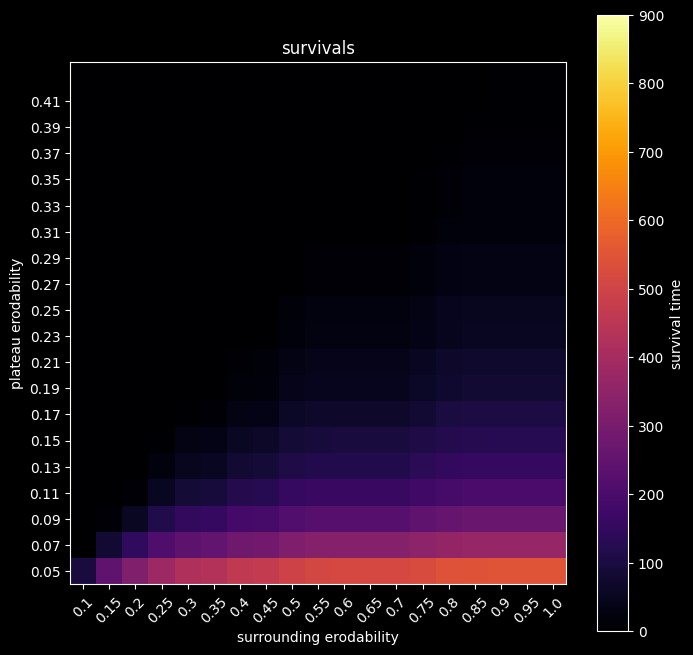

In [16]:
plt.figure(figsize=(8,8))
plt.imshow(A, cmap='inferno', origin='lower',vmin=0,vmax=900)
plt.colorbar(label='survival time')
plt.xticks(np.arange(19), (np.arange(19)*5+10)/100,rotation=45)
plt.xlabel("surrounding erodability")
plt.yticks(np.arange(19), (np.arange(19)*2+5)/100)
plt.ylabel("plateau erodability")
plt.title('survivals')
x=np.arange(20)
#plt.plot(x, x, color='red', linestyle='-')
plt.savefig("C:/ECS/survivals_tri.png")
plt.show()